# Assignment 5 - Weekly Reversal as a Two-Leg Long-Short Strategy

This notebook implements an investable version of the short-horizon Swiss equity reversal idea studied in the exploratory notebook. The economic intuition is simple: over short horizons, very strong recent winners may partially reverse, while very weak recent losers may rebound. We therefore build a strategy that buys recent losers and shorts recent winners.

The first implementable version uses weekly returns. Weekly rebalancing is a useful starting point because it reduces some of the noise and trading intensity of a daily reversal strategy, while still keeping the horizon short.

For each stock $i$ and week $t$, the reversal score is

$$
\text{Score}_{i,t} = - \frac{R_{i,t}}{\sigma_{i,t}},
$$

where $R_{i,t}$ is the stock return during week $t$ and $\sigma_{i,t}$ is the rolling weekly volatility estimate. The minus sign makes the interpretation natural:

- high score = negative recent return relative to volatility = recent loser = long candidate;
- low score = positive recent return relative to volatility = recent winner = short candidate.

The final strategy is franc-neutral. Instead of forcing a zero-net portfolio directly into the simulator, we backtest two normal baskets and combine them afterward:

$$
R^{\text{strategy}}_t
= 0.5 R^{\text{long losers}}_t
- 0.5 R^{\text{winner basket}}_t.
$$

This gives long exposure $+0.5$, short exposure $-0.5$, gross exposure $1.0$, and net exposure $0.0$. Short-borrow costs are ignored for now. Transaction costs are kept as configuration parameters and will be handled more carefully after validating the gross strategy mechanics.


## Backtest Design

The implementation is organized as a transparent sequence of steps:

- load the Swiss equity market data and SPI benchmark series;
- convert prices into close-to-close daily returns;
- aggregate daily returns into weekly returns;
- build a lagged volatility-scaled reversal score;
- filter the tradable universe using liquidity, trading-gap, and score-availability conditions;
- backtest the top-score basket as the long leg;
- backtest the bottom-score basket as the winner basket to be shorted;
- combine the two return series into the franc-neutral reversal strategy.

Each leg is a standard long-only basket internally. This is convenient because the usual portfolio simulation can float a fully invested basket between rebalancing dates. The franc-neutral exposure is then created explicitly in the return calculation by assigning weight $+0.5$ to the loser basket and weight $-0.5$ to the winner basket.


## Imports and Paths

The notebook uses the reusable backtesting objects from the course codebase. The `src` directory is added to `sys.path` so the local modules can be imported when the notebook is opened from the repository root or from the `assignments` folder.


In [1]:
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Locate the repository root by walking upward until the data folder is found.
PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"

# Make the local course modules importable inside the notebook.
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from backtesting.backtest import Backtest
from backtesting.backtest_data import BacktestData
from backtesting.backtest_item_builder.bib_classes import (
    OptimizationItemBuilder,
    SelectionItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
    bibfn_scores,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_jkp_data_scores,
    bibfn_selection_min_volume,
)
from backtesting.backtest_service import BacktestService
from optimization.optimization import PercentilePortfolio


## Configuration

The first test is deliberately small: two years of weekly rebalancing. This keeps the backtest quick enough to inspect while we validate that the signal, selection, portfolio construction, and return combination all behave as intended.


In [2]:
@dataclass(frozen=True)
class ReversalConfig:
    # Sample window used for the first implementation check.
    start_date: str = "2022-01-03"
    end_date: str = "2023-12-29"

    # Signal construction: weekly reversal scaled by rolling weekly volatility.
    horizon: str = "W"
    vol_lookback: int = 52
    min_vol_periods: int = 26

    # Portfolio construction: top 5% long, bottom 5% used as the short basket.
    leg_fraction: float = 0.05
    long_weight: float = 0.5
    short_weight: float = -0.5

    # Tradability filters: avoid illiquid names and stale price/volume histories.
    min_volume: int = 500_000
    volume_window_days: int = 252
    max_zero_volume_gap_days: int = 10
    lookback_days: int = 756

    # Cost parameters kept for later analysis. They are not applied in the first gross plot.
    transaction_costs_per_rebalancing: float = 0.002
    fixed_costs_annual: float = 0.01


CONFIG = ReversalConfig()

# PercentilePortfolio uses percentile thresholds. With a 5% leg, the long basket
# is above the 95th percentile and the short basket is below the 5th percentile.
TOP_PERCENTILE = int(100 * (1 - CONFIG.leg_fraction))
BOTTOM_PERCENTILE = int(100 * CONFIG.leg_fraction)


## Load Market Data

The market data panel is indexed by `(date, id)`, where each `id` is a stock. The main columns used here are price, market capitalization, liquidity, and sector information. The SPI file is a daily benchmark return series.


In [3]:
market_data = pd.read_parquet(DATA_DIR / "market_data.parquet").sort_index()

# Ensure that the date level is a proper DatetimeIndex. This keeps comparisons,
# resampling, and rolling windows consistent across the notebook.
date_level = market_data.index.names.index("date")
market_data.index = market_data.index.set_levels(
    pd.to_datetime(market_data.index.levels[date_level]),
    level="date",
)
market_data = market_data.sort_index()

spi = pd.read_csv(DATA_DIR / "spi_index.csv", index_col=0)
spi.index = pd.to_datetime(spi.index, dayfirst=True)
spi = spi["SPI"].sort_index()

# A compact data check before moving into the signal construction.
data_summary = pd.DataFrame(
    {
        "rows": [len(market_data), len(spi)],
        "start": [market_data.index.get_level_values("date").min(), spi.index.min()],
        "end": [market_data.index.get_level_values("date").max(), spi.index.max()],
    },
    index=["market_data", "spi"],
)

data_summary


,rows,start,end
market_data,1434082,1985-12-31,2024-04-30
spi,9251,1999-01-02,2024-04-30


## Price and Return Matrices

The signal is built from close-to-close stock returns. We first pivot prices into a wide matrix with dates in rows and stock ids in columns, then compute percentage changes stock by stock.

Missing prices are not forward-filled before computing returns. Forward-filling would create artificial zero returns and could distort a short-horizon reversal signal.


In [4]:
# Wide price matrix: each column is one stock, each row is one trading date.
prices = market_data.reset_index().pivot_table(
    index="date",
    columns="id",
    values="price",
    aggfunc="last",
).sort_index()

# Daily close-to-close returns. fill_method=None avoids implicit forward-filling.
daily_returns = prices.pct_change(fill_method=None)

pd.DataFrame(
    {
        "n_dates": [daily_returns.shape[0]],
        "n_stocks": [daily_returns.shape[1]],
        "first_date": [daily_returns.index.min()],
        "last_date": [daily_returns.index.max()],
    }
)


,n_dates,n_stocks,first_date,last_date
0,9978,313,1985-12-31,2024-04-30


## Weekly Volatility-Scaled Reversal Score

Daily returns are compounded into Friday-labelled weekly buckets:

$$
R_{i,t}^{W} = \prod_{d \in t} (1 + r_{i,d}) - 1.
$$

The volatility estimate is the rolling standard deviation of weekly returns over the previous 52 weeks, with at least 26 observations required. The score is then lagged by one week. This lag is important: the portfolio formed at a rebalance date must only use information that would already have been available before trading.


In [5]:
# Compound daily returns into weekly returns. min_count=3 avoids treating a week
# with too little price information as a valid full weekly observation.
weekly_returns = (1 + daily_returns).resample("W-FRI").prod(min_count=3) - 1

# Rolling weekly volatility used to compare moves across stocks with different risk levels.
weekly_volatility = weekly_returns.rolling(
    CONFIG.vol_lookback,
    min_periods=CONFIG.min_vol_periods,
).std()

# Reversal score: recent losers receive high scores because of the minus sign.
weekly_score = -weekly_returns / weekly_volatility

# Lag by one weekly observation to avoid forming portfolios with same-week information.
weekly_score = weekly_score.shift(1)

# The W-FRI label can fall on a holiday. For the backtest, map each weekly bucket
# to the actual last trading date observed inside that bucket.
weekly_last_trading_date = daily_returns.index.to_series().resample("W-FRI").last().dropna()
weekly_score = weekly_score.loc[weekly_score.index.intersection(weekly_last_trading_date.index)]
weekly_score.index = pd.DatetimeIndex(weekly_last_trading_date.loc[weekly_score.index].values)
weekly_score = weekly_score[~weekly_score.index.duplicated(keep="last")].sort_index()

# Convert the wide score matrix into a panel indexed by (date, id). This format
# can be joined with the market data and filtered at each rebalance date.
score_panel = weekly_score.stack().rename("reversal_score").to_frame()
score_panel.index = score_panel.index.set_names(["date", "id"])
score_panel = score_panel.replace([np.inf, -np.inf], np.nan).dropna().sort_index()

score_panel.head()


reversal_score
date       id                
1986-07-04 48        0.349271
1986-07-11 48        0.216246
1986-07-18 33        1.003388
           48        0.332767
1986-07-25 33        1.557402

## Build Backtest Data

The backtest data object collects the market panel, the score panel, and the benchmark series. Rebalancing dates are the weekly score dates inside the two-year sample window.


In [6]:
data = BacktestData()
data.market_data = market_data
data.jkp_data = score_panel
data.bm_series = spi

score_dates = pd.DatetimeIndex(score_panel.index.get_level_values("date").unique()).sort_values()
# Backtest portfolios store rebalance dates as strings, so keep the dates in ISO format.
rebalance_dates = [
    date.strftime("%Y-%m-%d")
    for date in score_dates
    if date >= pd.Timestamp(CONFIG.start_date) and date <= pd.Timestamp(CONFIG.end_date)
]

pd.DataFrame(
    {
        "n_rebalances": [len(rebalance_dates)],
        "first_rebalance": [rebalance_dates[0] if rebalance_dates else pd.NaT],
        "last_rebalance": [rebalance_dates[-1] if rebalance_dates else pd.NaT],
    }
)


,n_rebalances,first_rebalance,last_rebalance
0,104,2022-01-07,2023-12-29


## Selection and Optimization Inputs

At each rebalance, the tradable universe is restricted to stocks with enough liquidity, no long zero-volume gaps, and an available reversal score. The optimization inputs then pass the selected stock returns and selected scores into the portfolio construction rule.


In [7]:
selection_item_builders = {
    # Remove stocks with long stretches of zero volume, which are difficult to trade.
    "gaps": SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=CONFIG.lookback_days,
        n_days=CONFIG.max_zero_volume_gap_days,
    ),
    # Keep only stocks whose typical trading volume is large enough for this exercise.
    "min_volume": SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=CONFIG.volume_window_days,
        min_volume=CONFIG.min_volume,
        agg_fn=np.median,
    ),
    # A stock can enter either basket only if its reversal score is available.
    "jkp_data_scores": SelectionItemBuilder(
        bibfn=bibfn_selection_jkp_data_scores,
        fields=["reversal_score"],
    ),
}

optimization_item_builders = {
    # Historical returns are available for diagnostics and for the usual backtest objects.
    "return_series": OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=CONFIG.lookback_days,
        weekdays_only=True,
        fillna_value=0,
    ),
    # Scores are the direct input used by PercentilePortfolio to form the baskets.
    "scores": OptimizationItemBuilder(
        bibfn=bibfn_scores,
    ),
}


## Long Leg Backtest

The long leg buys the stocks with the highest reversal scores. These are the recent losers after volatility scaling. With a 5% leg size, the basket contains stocks above the 95th percentile of the score distribution at each rebalance.


In [8]:
long_leg = PercentilePortfolio(
    field="reversal_score",
    percentile=TOP_PERCENTILE,
    sign=">=",
)

bs_long = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    optimization=long_leg,
    rebdates=rebalance_dates,
    quiet=False,  # keep False to show the tqdm progress bar when the cell is executed
)


In [9]:
# Execute this cell when ready. It is intentionally not run while drafting the notebook.
bt_long = Backtest()
bt_long.run(bs=bs_long)


Running backtest: 100%|##########| 104/104 [04:30<00:00,  2.60s/it, 2023-12-29]


## Short Basket Backtest

The short side is first built as a normal long-only basket of recent winners. These are the stocks with the lowest reversal scores. Later, this basket return is multiplied by `-0.5` when constructing the franc-neutral strategy.


In [10]:
short_basket = PercentilePortfolio(
    field="reversal_score",
    percentile=BOTTOM_PERCENTILE,
    sign="<=",
)

bs_short = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    optimization=short_basket,
    rebdates=rebalance_dates,
    quiet=False,  # keep False to show the tqdm progress bar when the cell is executed
)


In [11]:
# Execute this cell after the long-leg backtest.
bt_short = Backtest()
bt_short.run(bs=bs_short)


Running backtest: 100%|##########| 104/104 [04:46<00:00,  2.75s/it, 2023-12-29]


## Combine the Two Legs

Both baskets are simulated as fully invested long-only portfolios. The franc-neutral strategy return is then computed explicitly:

$$
R^{\text{strategy}}_t
= 0.5 R^{\text{long losers}}_t
- 0.5 R^{\text{winner basket}}_t.
$$

The winner basket return shown below is therefore the performance of the stocks before applying the short sign. Short-borrow costs are not included in this first implementation.


In [12]:
# Run this cell after both backtests have been executed.
return_series = data.get_return_series(weekdays_only=True, fillna_value=0)
return_series = return_series.loc[
    (return_series.index >= pd.Timestamp(CONFIG.start_date))
    & (return_series.index <= pd.Timestamp(CONFIG.end_date))
]

# Gross leg returns with no transaction costs yet. Costs are easier to audit once
# the raw long and short basket mechanics have been validated.
long_leg_returns = bt_long.strategy.simulate(
    return_series=return_series,
    fc=0.0,
    vc=0.0,
).rename("long_recent_losers")

short_basket_returns = bt_short.strategy.simulate(
    return_series=return_series,
    fc=0.0,
    vc=0.0,
).rename("winner_basket_before_shorting")

leg_returns = pd.concat([long_leg_returns, short_basket_returns], axis=1).dropna()

strategy_returns = (
    CONFIG.long_weight * leg_returns["long_recent_losers"]
    + CONFIG.short_weight * leg_returns["winner_basket_before_shorting"]
).rename("franc_neutral_reversal")

all_strategy_returns = pd.concat([leg_returns, strategy_returns], axis=1).dropna()
all_strategy_returns.head()


,long_recent_losers,winner_basket_before_shorting,franc_neutral_reversal
date,,,
2022-01-10,-0.028083,-0.018017,-0.005033
2022-01-11,0.013442,-0.008782,0.011112
2022-01-12,0.017067,0.016772,0.000147
2022-01-13,0.012139,0.009617,0.001261
2022-01-14,-0.016810,0.006884,-0.011847


## Plot Return Series

The plot compares the two baskets and the final franc-neutral spread. The short basket line is not the short contribution; it is the standalone return of the winner basket before multiplying by the negative short exposure.


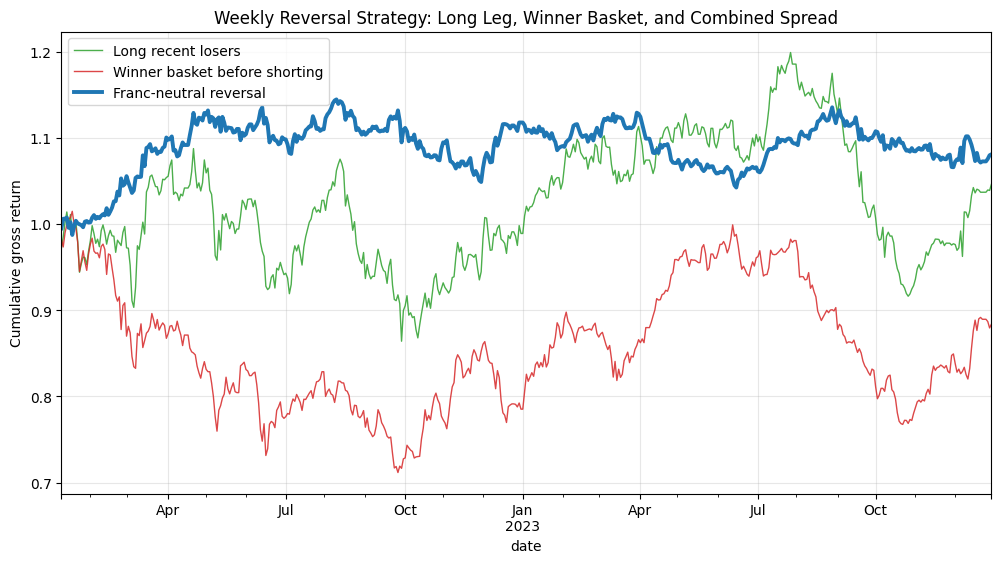

In [13]:
plot_data = all_strategy_returns.copy()
plot_data = plot_data.dropna()

cumulative_returns = (1 + plot_data).cumprod()

ax = cumulative_returns["long_recent_losers"].plot(
    figsize=(12, 6),
    color="C2",      # standard matplotlib green
    linewidth=1.0,
    alpha=0.85,
    label="Long recent losers",
)

cumulative_returns["winner_basket_before_shorting"].plot(
    ax=ax,
    color="C3",      # standard matplotlib red
    linewidth=1.0,
    alpha=0.85,
    label="Winner basket before shorting",
)

cumulative_returns["franc_neutral_reversal"].plot(
    ax=ax,
    color="C0",      # standard matplotlib blue
    linewidth=2.8,
    label="Franc-neutral reversal",
)

ax.set_title("Weekly Reversal Strategy: Long Leg, Winner Basket, and Combined Spread")
ax.set_ylabel("Cumulative gross return")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Including Transaction Costs

In [14]:
# Turnover of each basket at each rebalance date.
long_turnover = bt_long.strategy.turnover(
    return_series=return_series,
    rescale=False,
)

short_basket_turnover = bt_short.strategy.turnover(
    return_series=return_series,
    rescale=False,
)

long_turnover.index = pd.to_datetime(long_turnover.index)
short_basket_turnover.index = pd.to_datetime(short_basket_turnover.index)

# Combined turnover of the franc-neutral strategy.
# Each basket is used with 50% gross exposure.
combined_turnover = (
    abs(CONFIG.long_weight) * long_turnover
    + abs(CONFIG.short_weight) * short_basket_turnover
).rename("combined_turnover")

# Transaction cost paid at rebalance dates.
transaction_costs = (
    combined_turnover * CONFIG.transaction_costs_per_rebalancing
).rename("transaction_costs")

# Start from gross combined strategy return.
strategy_returns_net = strategy_returns.copy().rename("franc_neutral_reversal_net")

# Subtract transaction costs on the first return date at or after each rebalance.
for rebalance_date, cost in transaction_costs.items():
    future_dates = strategy_returns_net.index[strategy_returns_net.index >= rebalance_date]
    if len(future_dates) > 0:
        strategy_returns_net.loc[future_dates[0]] -= cost

# Optional fixed-cost drag.
elapsed_days = strategy_returns_net.index.to_series().diff().dt.days.fillna(0)
fixed_cost_drag = (1 + CONFIG.fixed_costs_annual) ** (elapsed_days / 252) - 1

strategy_returns_net = (
    strategy_returns_net - fixed_cost_drag
).rename("franc_neutral_reversal_net")

pd.concat(
    {
        "gross": strategy_returns,
        "net": strategy_returns_net,
        "transaction_costs": transaction_costs,
        "turnover": combined_turnover,
    },
    axis=1,
).head()

C:\Users\axeli\AppData\Local\Temp\ipykernel_32920\148414591.py:44: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  pd.concat(


,gross,net,transaction_costs,turnover
2022-01-07,NaN,NaN,0.002,1.0
2022-01-10,-0.005033,-0.007033,NaN,NaN
2022-01-11,0.011112,0.011072,NaN,NaN
2022-01-12,0.000147,0.000108,NaN,NaN
2022-01-13,0.001261,0.001221,NaN,NaN


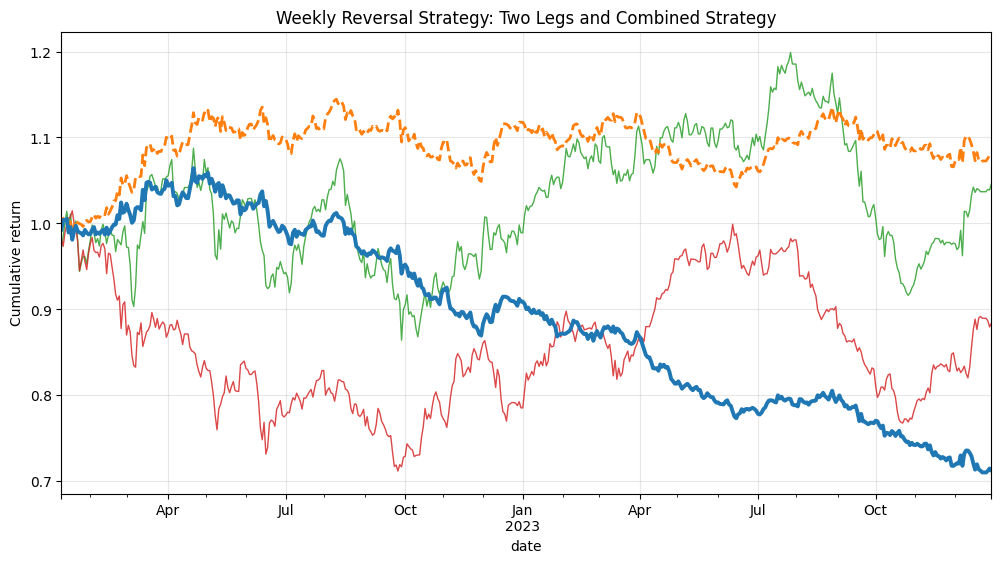

In [15]:
plot_data = pd.concat(
    {
        "Long recent losers": all_strategy_returns["long_recent_losers"],
        "Winner basket before shorting": all_strategy_returns["winner_basket_before_shorting"],
        "Franc-neutral reversal gross": strategy_returns,
        "Franc-neutral reversal net": strategy_returns_net,
    },
    axis=1,
).dropna()

cumulative_returns = (1 + plot_data).cumprod()

ax = cumulative_returns["Long recent losers"].plot(
    figsize=(12, 6),
    color="C2",      # matplotlib standard green
    linewidth=1.0,
    alpha=0.85,
)

cumulative_returns["Winner basket before shorting"].plot(
    ax=ax,
    color="C3",      # matplotlib standard red
    linewidth=1.0,
    alpha=0.85,
)

cumulative_returns["Franc-neutral reversal gross"].plot(
    ax=ax,
    color="C1",      # matplotlib standard orange
    linewidth=2.0,
    linestyle="--",
)

cumulative_returns["Franc-neutral reversal net"].plot(
    ax=ax,
    color="C0",      # matplotlib standard blue
    linewidth=2.8,
)

ax.set_title("Weekly Reversal Strategy: Two Legs and Combined Strategy")
ax.set_ylabel("Cumulative return")
ax.grid(True, alpha=0.3)
plt.show()

## Quick Diagnostics

These checks are meant to be run after the two backtests. They verify how many portfolios were created, how many stocks are selected in the first rebalance, and whether each leg is internally fully invested before the final long-short combination.


In [16]:
first_long_weights = pd.Series(bt_long.strategy.portfolios[0].weights, dtype=float)
first_short_basket_weights = pd.Series(bt_short.strategy.portfolios[0].weights, dtype=float)

diagnostics = pd.DataFrame(
    {
        "long_leg": {
            "n_rebalances": len(bt_long.strategy.portfolios),
            "n_names_first_rebalance": first_long_weights.gt(0).sum(),
            "weight_sum_first_rebalance": first_long_weights.sum(),
        },
        "winner_basket": {
            "n_rebalances": len(bt_short.strategy.portfolios),
            "n_names_first_rebalance": first_short_basket_weights.gt(0).sum(),
            "weight_sum_first_rebalance": first_short_basket_weights.sum(),
        },
    }
)

diagnostics


,long_leg,winner_basket
n_rebalances,104.0,104.0
n_names_first_rebalance,6.0,6.0
weight_sum_first_rebalance,1.0,1.0


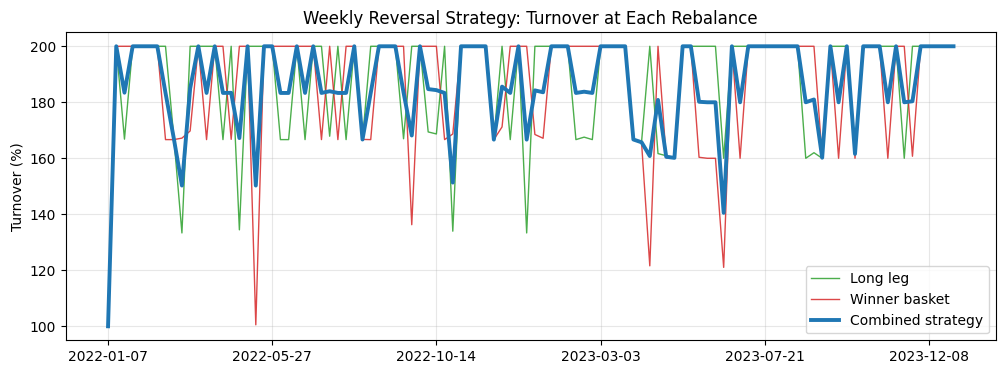

In [17]:
long_turnover = bt_long.strategy.turnover(return_series=return_series)
short_basket_turnover = bt_short.strategy.turnover(return_series=return_series)

turnover_summary = pd.concat(
    {
        "Long leg": long_turnover,
        "Winner basket": short_basket_turnover,
        "Combined strategy": (
            abs(CONFIG.long_weight) * long_turnover
            + abs(CONFIG.short_weight) * short_basket_turnover
        ),
    },
    axis=1,
).dropna()

ax = (100 * turnover_summary["Long leg"]).plot(
    figsize=(12, 4),
    color="C2",
    linewidth=1.0,
    alpha=0.85,
    label="Long leg",
)

(100 * turnover_summary["Winner basket"]).plot(
    ax=ax,
    color="C3",
    linewidth=1.0,
    alpha=0.85,
    label="Winner basket",
)

(100 * turnover_summary["Combined strategy"]).plot(
    ax=ax,
    color="C0",
    linewidth=2.8,
    label="Combined strategy",
)

ax.set_title("Weekly Reversal Strategy: Turnover at Each Rebalance")
ax.set_ylabel("Turnover (%)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

In [18]:
# Inspect the first names selected in each leg. The winner basket weights are
# positive here because the basket is simulated first and shorted only afterward.
first_portfolios = pd.concat(
    {
        "long_recent_losers": first_long_weights.sort_values(ascending=False).head(10),
        "winner_basket_before_shorting": first_short_basket_weights.sort_values(ascending=False).head(10),
    },
    axis=1,
)

first_portfolios


,long_recent_losers,winner_basket_before_shorting
13,0.166667,NaN
229,0.166667,NaN
243,0.166667,NaN
246,0.166667,NaN
270,0.166667,NaN
288,0.166667,NaN
126,NaN,0.166667
177,NaN,0.166667
213,NaN,0.166667
227,NaN,0.166667


## EMA Smoothing of Portfolio Weights

The weekly reversal strategy can generate high turnover because the top and bottom score baskets may change substantially from one rebalance to the next. This is important for implementation: even if the gross signal is profitable, excessive turnover can reduce or eliminate performance after transaction costs.

To study this, we test a simple exponential moving average (EMA) smoothing rule on the target portfolio weights. Let \(w_t^{raw}\) be the raw franc-neutral target weight vector at rebalance date \(t\). The smoothed target is defined as:

\[
w_t^{EMA}(\lambda)
=
\lambda w_t^{raw}
+
(1-\lambda) w_{t-1}^{EMA},
\]

where \(\lambda \in [0,1]\) controls the speed of adjustment:

- high \(\lambda\): the portfolio moves quickly toward the new signal, staying close to the original strategy;
- low \(\lambda\): the portfolio changes more slowly, which should reduce turnover but may delay the reversal signal.

After smoothing, we clean very small residual positions by setting weights with absolute value below \(0.001\) to zero. This avoids keeping tiny positions that are not meaningful in practice and may create unnecessary turnover.

Finally, after clipping, the long and short sides are re-normalized separately so the strategy remains approximately franc-neutral:

\[
\sum_{i:w_{i,t}>0} w_{i,t} = 0.5,
\qquad
\sum_{i:w_{i,t}<0} w_{i,t} = -0.5.
\]

For each value of \(\lambda\), we will compute daily portfolio returns from the smoothed weights, subtract transaction costs based on turnover, and compare performance using the Sharpe ratio.

In [19]:
# Extract raw target weights from the two backtested legs.
# Each row is a rebalance date and each column is a stock id.

long_weights = pd.DataFrame(
    {
        portfolio.rebalancing_date: pd.Series(portfolio.weights, dtype=float)
        for portfolio in bt_long.strategy.portfolios
    }
).T.fillna(0)

short_basket_weights = pd.DataFrame(
    {
        portfolio.rebalancing_date: pd.Series(portfolio.weights, dtype=float)
        for portfolio in bt_short.strategy.portfolios
    }
).T.fillna(0)

# Convert index to DatetimeIndex so weights align naturally with daily returns.
long_weights.index = pd.to_datetime(long_weights.index)
short_basket_weights.index = pd.to_datetime(short_basket_weights.index)

# Make sure both matrices have the same stock columns.
all_ids = long_weights.columns.union(short_basket_weights.columns)
long_weights = long_weights.reindex(columns=all_ids, fill_value=0)
short_basket_weights = short_basket_weights.reindex(columns=all_ids, fill_value=0)

# Combine the two long-only baskets into signed franc-neutral target weights.
# The winner basket is multiplied by the negative short exposure.
raw_weights = (
    CONFIG.long_weight * long_weights
    + CONFIG.short_weight * short_basket_weights
).fillna(0)

# Quick exposure check: the raw strategy should be close to +0.5 long, -0.5 short.
raw_exposures = pd.DataFrame(
    {
        "long_exposure": raw_weights.clip(lower=0).sum(axis=1),
        "short_exposure": raw_weights.clip(upper=0).sum(axis=1),
        "gross_exposure": raw_weights.abs().sum(axis=1),
        "net_exposure": raw_weights.sum(axis=1),
    }
)

raw_exposures.head()

,long_exposure,short_exposure,gross_exposure,net_exposure
2022-01-07,0.5,-0.5,1.0,-2.775558e-17
2022-01-14,0.5,-0.5,1.0,0.000000e+00
2022-01-21,0.5,-0.5,1.0,0.000000e+00
2022-01-28,0.5,-0.5,1.0,0.000000e+00
2022-02-04,0.5,-0.5,1.0,0.000000e+00


In [20]:
def evaluate_ema_lambda(
    lambda_: float,
    raw_weights: pd.DataFrame,
    return_series: pd.DataFrame,
    transaction_cost: float,
    weight_floor: float = 0.001,
    n_days_per_year: int = 252,
) -> dict:
    """
    Evaluate one EMA smoothing parameter for the franc-neutral reversal strategy.

    The function:
    1. smooths raw rebalance weights with an EMA;
    2. removes very small positions;
    3. re-normalizes long and short sides separately;
    4. computes daily gross returns;
    5. subtracts transaction costs at rebalance dates;
    6. returns net performance metrics.
    """

    # Smooth target weights across rebalance dates.
    # alpha=lambda_ means the new portfolio moves lambda_ of the way toward
    # the new raw target at each rebalance.
    smoothed_weights = raw_weights.ewm(alpha=lambda_, adjust=False).mean()

    # Remove tiny EMA residuals. These positions are too small to be meaningful
    # and can otherwise create artificial turnover.
    smoothed_weights = smoothed_weights.mask(smoothed_weights.abs() < weight_floor, 0.0)

    # Re-normalize long and short sides separately after smoothing and clipping.
    # This keeps the strategy close to +0.5 long exposure and -0.5 short exposure.
    long_side = smoothed_weights.clip(lower=0)
    short_side = smoothed_weights.clip(upper=0)

    long_sum = long_side.sum(axis=1).replace(0, np.nan)
    short_sum = short_side.abs().sum(axis=1).replace(0, np.nan)

    long_side = long_side.div(long_sum, axis=0) * CONFIG.long_weight
    short_side = short_side.div(short_sum, axis=0) * abs(CONFIG.short_weight)

    weights = (long_side + short_side).fillna(0)

    # Align weights with the daily return matrix and hold each rebalance portfolio
    # until the next rebalance date.
    daily_weights = (
        weights
        .reindex(return_series.index)
        .ffill()
        .fillna(0)
    )

    # Use yesterday's weights for today's returns to avoid look-ahead bias.
    gross_returns = (
        daily_weights.shift(1).fillna(0) * return_series.reindex(columns=daily_weights.columns).fillna(0)
    ).sum(axis=1)

    # Turnover is computed only on rebalance dates from target weights.
    # It measures how much signed notional changes from one target portfolio to the next.
    turnover = weights.diff().abs().sum(axis=1)
    if len(turnover) > 0:
        turnover.iloc[0] = weights.iloc[0].abs().sum()

    transaction_costs = turnover * transaction_cost

    # Subtract transaction costs on the first available return date at or after each rebalance.
    net_returns = gross_returns.copy()
    for rebalance_date, cost in transaction_costs.items():
        future_dates = net_returns.index[net_returns.index >= rebalance_date]
        if len(future_dates) > 0:
            net_returns.loc[future_dates[0]] -= cost

    # Performance metrics.
    avg_daily_return = net_returns.mean()
    annualized_return = avg_daily_return * n_days_per_year
    annualized_volatility = net_returns.std() * np.sqrt(n_days_per_year)

    sharpe_ratio = (
        annualized_return / annualized_volatility
        if annualized_volatility > 0
        else np.nan
    )

    return {
        "lambda": lambda_,
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
        "sharpe_ratio": sharpe_ratio,
        "average_turnover": turnover.mean(),
        "net_returns": net_returns,
        "weights": weights,
        "turnover": turnover,
        "transaction_costs": transaction_costs,
    }

In [21]:
from tqdm import tqdm

# Grid of EMA smoothing parameters.
# lambda = 0 would never move away from the first target portfolio, so we start at 0.05.
lambda_grid = np.arange(0.05, 1.01, 0.05)

ema_results = []

for lambda_ in tqdm(lambda_grid, desc="Testing EMA lambdas"):
    result = evaluate_ema_lambda(
        lambda_=lambda_,
        raw_weights=raw_weights,
        return_series=return_series,
        transaction_cost=CONFIG.transaction_costs_per_rebalancing,
        weight_floor=0.001,
    )

    # Store only scalar metrics in the summary table.
    # Full return series and weights remain available in ema_results_full.
    ema_results.append(
        {
            "lambda": result["lambda"],
            "annualized_return": result["annualized_return"],
            "annualized_volatility": result["annualized_volatility"],
            "sharpe_ratio": result["sharpe_ratio"],
            "average_turnover": result["average_turnover"],
        }
    )

ema_summary = pd.DataFrame(ema_results).set_index("lambda")

best_lambda = ema_summary["sharpe_ratio"].idxmax()
best_sharpe = ema_summary.loc[best_lambda, "sharpe_ratio"]

print(f"Best lambda by net Sharpe ratio: {best_lambda:.2f}")
print(f"Best net Sharpe ratio: {best_sharpe:.2f}")

ema_summary

Testing EMA lambdas: 100%|██████████| 20/20 [00:00<00:00, 44.60it/s]

Best lambda by net Sharpe ratio: 0.05
Best net Sharpe ratio: -0.92


,annualized_return,annualized_volatility,sharpe_ratio,average_turnover
lambda,,,,
0.05,-0.064018,0.069509,-0.921011,0.159168
0.10,-0.090698,0.060785,-1.492102,0.272452
0.15,-0.099554,0.057919,-1.718863,0.375520
0.20,-0.102550,0.057452,-1.784950,0.472319
0.25,-0.105241,0.058502,-1.798925,0.566161
0.30,-0.107873,0.060135,-1.793839,0.658065
0.35,-0.109830,0.062081,-1.769142,0.749302
0.40,-0.111200,0.064068,-1.735664,0.839052
0.45,-0.112043,0.066074,-1.695728,0.926175


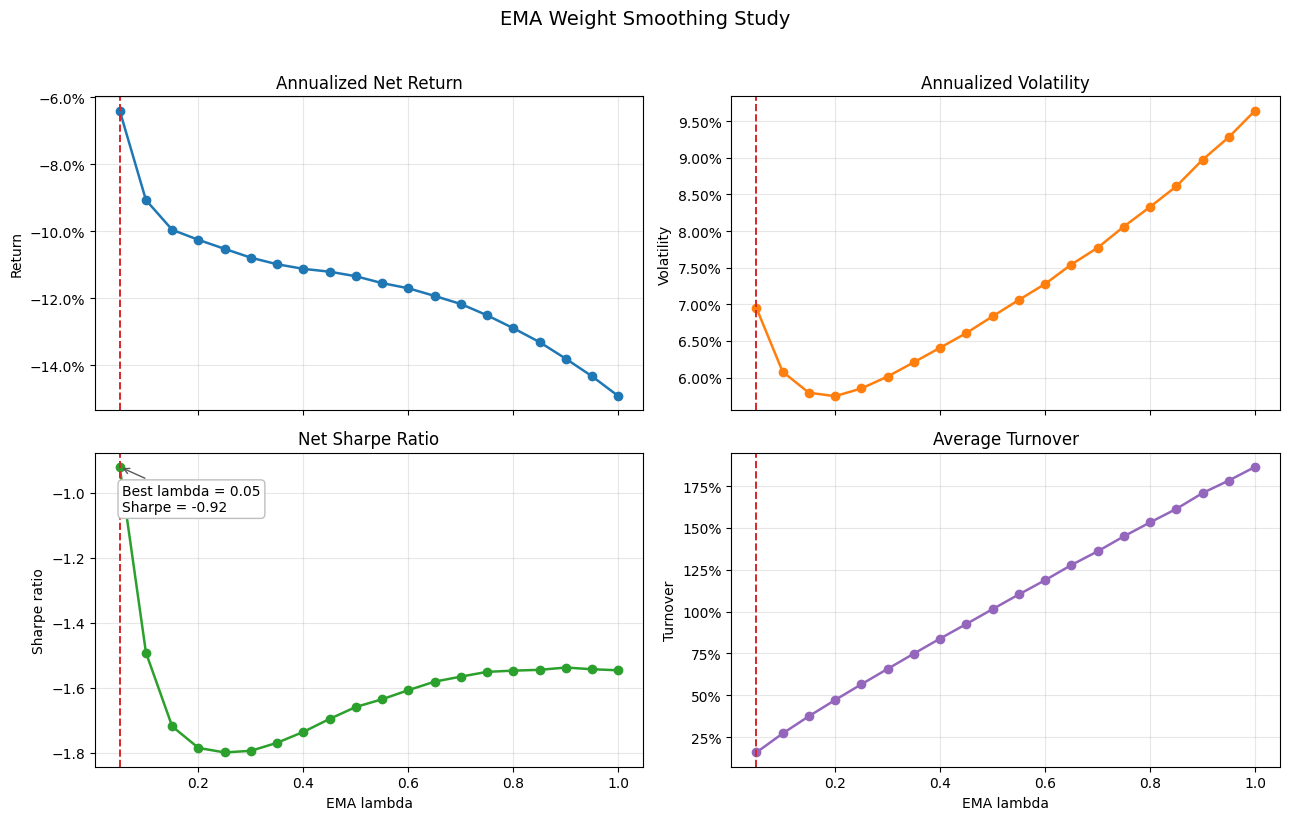

In [22]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes = axes.ravel()

# Panel 1: annualized net return. This shows how much performance remains
# after the turnover reduction and transaction-cost adjustment.
ema_summary["annualized_return"].plot(
    ax=axes[0],
    color="C0",
    marker="o",
    linewidth=1.8,
)
axes[0].axvline(best_lambda, color="C3", linestyle="--", linewidth=1.4)
axes[0].set_title("Annualized Net Return")
axes[0].set_ylabel("Return")
axes[0].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[0].grid(True, alpha=0.3)

# Panel 2: annualized volatility. Smoothing can change risk because the
# portfolio reacts more slowly to new reversal signals.
ema_summary["annualized_volatility"].plot(
    ax=axes[1],
    color="C1",
    marker="o",
    linewidth=1.8,
)
axes[1].axvline(best_lambda, color="C3", linestyle="--", linewidth=1.4)
axes[1].set_title("Annualized Volatility")
axes[1].set_ylabel("Volatility")
axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[1].grid(True, alpha=0.3)

# Panel 3: net Sharpe ratio. The selected lambda maximizes this metric on
# the current sample, so this is the main tuning plot.
ema_summary["sharpe_ratio"].plot(
    ax=axes[2],
    color="C2",
    marker="o",
    linewidth=1.8,
)
axes[2].axvline(best_lambda, color="C3", linestyle="--", linewidth=1.4)
axes[2].set_title("Net Sharpe Ratio")
axes[2].set_xlabel("EMA lambda")
axes[2].set_ylabel("Sharpe ratio")
axes[2].grid(True, alpha=0.3)
axes[2].annotate(
    f"Best lambda = {best_lambda:.2f}\nSharpe = {best_sharpe:.2f}",
    xy=(best_lambda, best_sharpe),
    xytext=(0.05, 0.90),
    textcoords="axes fraction",
    ha="left",
    va="top",
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "0.75"},
    arrowprops={"arrowstyle": "->", "color": "0.35", "linewidth": 1.0},
)

# Panel 4: average turnover. This is the implementation channel through
# which EMA smoothing is expected to help after transaction costs.
ema_summary["average_turnover"].plot(
    ax=axes[3],
    color="C4",
    marker="o",
    linewidth=1.8,
)
axes[3].axvline(best_lambda, color="C3", linestyle="--", linewidth=1.4)
axes[3].set_title("Average Turnover")
axes[3].set_xlabel("EMA lambda")
axes[3].set_ylabel("Turnover")
axes[3].yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
axes[3].grid(True, alpha=0.3)

fig.suptitle("EMA Weight Smoothing Study", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()


## Current Status and Next Steps

The notebook now sets up the weekly volatility-scaled reversal score, applies tradability filters, builds the top-score and bottom-score baskets separately, combines their simulated returns into a franc-neutral spread, and provides simple plots and diagnostics.

The next steps are to run and validate the two-year backtest, inspect turnover, apply transaction costs carefully, audit extreme stock returns, extend the implementation to the daily horizon, compare the strategy more formally against the SPI, and add robustness checks before drawing final conclusions.
